In [64]:
import tempfile
import numpy as np

import litebird_sim as lbs
import brahmap

import healpy as hp
from matplotlib import pyplot as plt

import os

from scipy.sparse.linalg import cg, LinearOperator
from scipy.interpolate import CubicSpline

import time

from utils import inpainting_func


In [65]:
plt.rcParams.update({
    "font.size":9,
    "text.usetex":True,
    "font.family":"serif", 
    "font.serif":"Computer Modern Roman"
    })

In [66]:
###############################################################################
####### Producing the input maps, pointings and TODs using litebird_sim #######
###############################################################################

realization = 0

### same sampling rate as for the full simulations
n_samples_pow = 2**29                          
sampling_rate_hz = n_samples_pow/3600/24/365.25 # corresponding to 365.25 days of mission (~17 Hz)

fknee_mhz = 1e2                                 # pessimistic f_knee
alpha = 2                                       # pessimistic alpha
fmin_hz = 1e-8                                  # ~1157 days, longer than the longest chunk we consider (~22.8 days)
net_detector_ukrts = 50.0

###

base_path = 'output'

### Mission parameters
start_time = 51
mission_time_days = n_samples_pow/sampling_rate_hz/3600/24

In [67]:
nsamp_fknee = sampling_rate_hz/(fknee_mhz*1e-3)
nsamp_avg = int(nsamp_fknee//2)

In [68]:
### Simulation parameters
random_seed = realization
imo_version = "vPTEP"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
dtype_float = np.float64
tmp_dir = tempfile.TemporaryDirectory()


### Scanning strategy parameters
spin_sun_angle_deg = 37.5
spin_sun_angle_rad = np.deg2rad(spin_sun_angle_deg)
spin_boresight_angle_rad = np.deg2rad(95-spin_sun_angle_deg)
spin_rate_hz = 0.3 / 60.0
precession_rate_hz = 1/(192.348 * 60)


instr_info = lbs.InstrumentInfo(
    spin_boresight_angle_rad = spin_boresight_angle_rad,
)


ch_info = lbs.FreqChannelInfo(
    bandcenter_ghz=100.0,                   # value for "MF1-100" from Option 1 IMo
    bandwidth_ghz=0.23,                     # value for "MF1-100" from Option 1 IMo
    fwhm_arcmin=20.0,                       # ref value
    net_detector_ukrts=net_detector_ukrts,  # ref value
    fknee_mhz=fknee_mhz,
    fmin_hz=fmin_hz,
    alpha=alpha,
    sampling_rate_hz=sampling_rate_hz,
)


pol_angles_rad = [0., np.pi/2]
n_detectors = len(pol_angles_rad)


### Detector list
detector_list = []
for i in range(n_detectors):
    det = ch_info.get_boresight_detector(name=f"Dummy_det_#{i+1}")
    det.pol_angle_rad = pol_angles_rad[i]
    detector_list.append(det)


################################################################################


### Initializing the simulation
sim = lbs.Simulation(
        random_seed=random_seed,
        base_path=tmp_dir.name,
        name="brahmap_example",
        start_time=start_time,
        duration_s=mission_time_days * 24 * 60 * 60.0,
        imo=imo,
        )


### Create observations
sim.create_observations(
        detectors=detector_list,
        num_of_obs_per_detector=1,
        n_blocks_det=1,
        n_blocks_time=1,
        split_list_over_processes=False,
        tod_dtype=dtype_float,
)

In [69]:
### Adding 1/f noise
lbs.noise.add_noise_to_observations(
    sim.observations, "one_over_f", dets_random=sim.dets_random
)

tod_chunk = np.copy(sim.observations[0].tod[0])

34.24 hours of data
8.03 mins of INPAINTED data


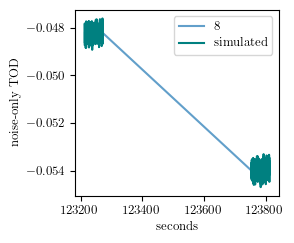

<Figure size 640x480 with 0 Axes>

: 

In [ ]:
####################################################
# BINNING
####################################################

fknee_hz = fknee_mhz*1e-3

n_samples_sub = n_samples_pow//2**8

print(f"{n_samples_sub/sampling_rate_hz/3600:.2f} hours of data")

TOD_oof = tod_chunk[:n_samples_sub]
nsamp_y = len(TOD_oof)

nsamp_x = 2**13

print(f"{nsamp_x/sampling_rate_hz/60:.2f} mins of INPAINTED data")

n_samp_assumed = nsamp_x + nsamp_y

plt.figure(figsize=(3, 2.5))

#plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,x_sol_ref, color='lightseagreen', alpha=0.7, label=r'inpainted')

bin_size = 8

x_sol = inpainting_func(TOD_oof, nsamp_x, net_detector_ukrts, fknee_hz, alpha, fmin_hz, sampling_rate_hz, bin_size)

plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz, x_sol, alpha=0.7, label=f'{bin_size}')

plt.plot(np.arange(nsamp_y)[-1000:]/sampling_rate_hz,TOD_oof[-1000:], color='teal', label=r'simulated')
plt.plot((nsamp_y+nsamp_x)/sampling_rate_hz+np.arange(nsamp_y)[:1000]/sampling_rate_hz,TOD_oof[:1000], color='teal')

plt.xlabel(r'seconds')
plt.ylabel(r'noise-only TOD')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("output/bin_size.pdf")
plt.show()
plt.clf()

In [59]:
def check_lr(left,right):
    '''
    Checks if the arguments left and right are well defined (they must be different)
    '''
    if left == right:
        print('one (and only one) argument between left and right must be True!')

def check_Pv(P,v):
    '''
    Checks if the arguments P and v are well defined (len(v) must be len(P)-1)
    '''
    if len(v) != len(P)-1:
        print('len(v) must be len(P)-1!')
        print('len(v) =', len(v), 'len(P) =', len(P))

def padding(v,N,left=False,right=False):
    '''
    Given v, returns a padded vector, (0,v) or (v,0) depending on whether left or right are True.
    
    ARGUMENTS____________________________________________ 
    v:     vector to be padded
    N:     final length of the padded vector
    left:  if true, returns (0,v) 
    right: if true, returns (v,0) 
    '''
    check_lr(left,right)
    n = len(v)
    z = np.zeros(N)
    if right == True:
        z[:n] = v
    else:
        z[-n:] = v    
    return z

def A_func(P,v,nx,left=False,right=False):
    # z = padded v
    # A(z) = IDFT(1/P * DFT(z))
    check_lr(left,right)
    n = len(v)
    N = len(P)
    z = padding(v,N,left,right)
    #check_Pv(P,z)
    z_fft = np.fft.fft(z)
    product = 1/P * z_fft
    result = np.fft.ifft(product).real
    return result[:nx]


In [60]:
n_samples_sub = n_samples_pow//2**8

print(f"{n_samples_sub/sampling_rate_hz/3600:.2f} hours of data")

TOD_oof = tod_chunk[:n_samples_sub]
nsamp_y = len(TOD_oof)

34.24 hours of data


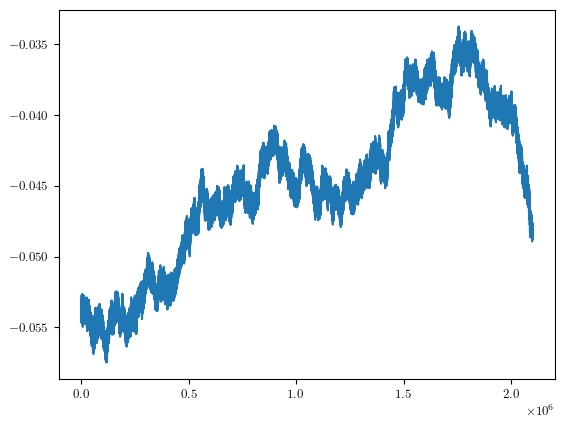

In [61]:
plt.plot(TOD_oof)

34.24 hours of data
8.03 mins of INPAINTED data
it took 3.951564073562622 seconds to converge!


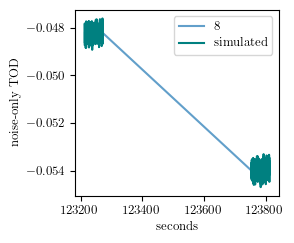

<Figure size 640x480 with 0 Axes>

In [ ]:
####################################################
# BINNING
####################################################

n_samples_sub = n_samples_pow//2**8

print(f"{n_samples_sub/sampling_rate_hz/3600:.2f} hours of data")

TOD_oof = tod_chunk[:n_samples_sub]
nsamp_y = len(TOD_oof)

nsamp_x = 2**13

print(f"{nsamp_x/sampling_rate_hz/60:.2f} mins of INPAINTED data")

n_samp_assumed = nsamp_x + nsamp_y

plt.figure(figsize=(3, 2.5))

#plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,x_sol_ref, color='lightseagreen', alpha=0.7, label=r'inpainted')

bin_size = 8

data = np.copy(TOD_oof)

# Reshape into a 2D grid and take the mean along the horizontal axis
binned_means = data.reshape(-1, bin_size).mean(axis=1)

binned_nsamp_x = nsamp_x//bin_size

# full frequencies and power spectrum
freqs = np.fft.fftfreq(int(n_samp_assumed/bin_size), d=1/(sampling_rate_hz/bin_size)) 
sigma = net_detector_ukrts * np.sqrt(sampling_rate_hz) / 1e6 #as in rescale_noise
P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

b = -A_func(P_oof, binned_means, binned_nsamp_x, left=True)	#A_func applied to a vector [0,y]

def A_func_x_only(x):
    return A_func(P_oof, x, binned_nsamp_x, right=True)	#A_func applied to a vector [x,0]

# Define the LinearOperator for CG
A_op = LinearOperator((binned_nsamp_x,binned_nsamp_x), matvec=A_func_x_only)

## in case we want to add an initial guess for x
avg_head = np.mean(TOD_oof[:nsamp_avg])
avg_tail = np.mean(TOD_oof[-nsamp_avg:])
x0 = avg_tail + np.arange(binned_nsamp_x)/binned_nsamp_x*(avg_head-avg_tail)

start = time.time()

x_sol, info = cg(A_op, b, rtol=1e-10, x0=x0)

if info == 0:
    print("it took "+str((time.time()-start))+" seconds to converge!")
else:
    print("CG did not converge, info =", info)

x = bin_size*(1/2 + np.arange(binned_nsamp_x))
y = x_sol
cs = CubicSpline(x, y)

x_sol_10_binned_spline = cs(np.arange(nsamp_x))

plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz, x_sol_10_binned_spline, alpha=0.7, label=f'{bin_size}')

plt.plot(np.arange(nsamp_y)[-1000:]/sampling_rate_hz,TOD_oof[-1000:], color='teal', label=r'simulated')
plt.plot((nsamp_y+nsamp_x)/sampling_rate_hz+np.arange(nsamp_y)[:1000]/sampling_rate_hz,TOD_oof[:1000], color='teal')

plt.xlabel(r'seconds')
plt.ylabel(r'noise-only TOD')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("output/bin_size.pdf")
plt.show()
plt.clf()

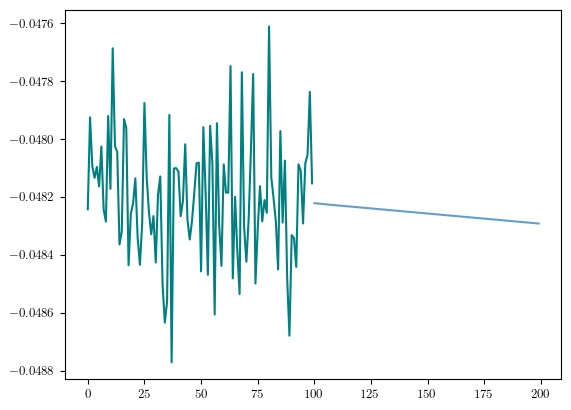

In [63]:
plt.plot(100+np.arange(100), x_sol_10_binned_spline[:100], alpha=0.7, label=f'{bin_size}')
plt.plot(TOD_oof[-100:], color='teal')

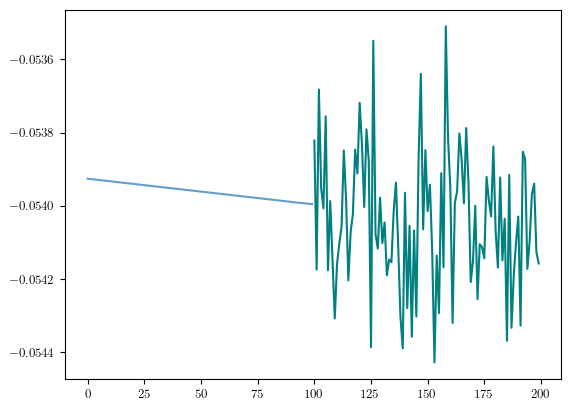

In [58]:
plt.plot(x_sol_10_binned_spline[-100:], alpha=0.7, label=f'{bin_size}')
plt.plot(100+np.arange(100), TOD_oof[:100], color='teal')

KeyboardInterrupt: 

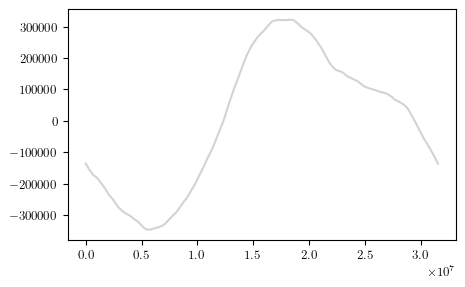

In [ ]:
####################################################
# INPAINTING
####################################################

n_samples_sub = n_samples_pow//16
TOD_oof = tod_chunk[:n_samples_sub]
nsamp_y = len(TOD_oof)

### Plotting and comparing the input and output maps
plt.figure(figsize=(5, 3))

plt.plot(np.arange(n_samples_pow)/sampling_rate_hz,tod_chunk, color='lightgray')

for nsamp_x in [20000]:

    n_samp_assumed = nsamp_x + nsamp_y

    freqs = np.fft.fftfreq(n_samp_assumed, d=1/sampling_rate_hz) 

    sigma = net_detector_ukrts * np.sqrt(sampling_rate_hz) / 1e6 #as in rescale_noise
    P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

    b = -A_func(P_oof, TOD_oof, nsamp_x, left=True)	#A_func applied to a vector [0,y]

    def A_func_x_only(x):
        return A_func(P_oof, x, nsamp_x, right=True)	#A_func applied to a vector [x,0]

    # Define the LinearOperator for CG
    A_op = LinearOperator((nsamp_x,nsamp_x), matvec=A_func_x_only)

    ## in case we want to add an initial guess for x
    avg_head = np.mean(TOD_oof[:nsamp_avg])
    avg_tail = np.mean(TOD_oof[-nsamp_avg:])
    x0 = avg_tail + np.arange(nsamp_x)/nsamp_x*(avg_head-avg_tail)

    start = time.time()

    x_sol, info = cg(A_op, b, rtol=1e-10, x0=x0)

    if info == 0:
        print("it took "+str((time.time()-start)/60)+" minutes to converge!")
    else:
        print("CG did not converge, info =", info)

    if nsamp_x == n_samples_pow - nsamp_y:
        plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,x_sol, color='lightseagreen', alpha=0.7, label=r'inpainted')
    else:
        plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,x_sol, color='lightseagreen', alpha=0.3, linestyle=r'dotted')
        

plt.plot(np.arange(n_samples_pow)/sampling_rate_hz,np.ones(n_samples_pow)*x_sol[-1], color='dimgrey', alpha=0.7, linestyle=':')
plt.plot(np.arange(nsamp_y)/sampling_rate_hz,TOD_oof, color='teal', label=r'simulated')
plt.xlabel(r'seconds')
plt.ylabel(r'noise-only TOD')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("output/toy_inp.pdf")
plt.show()
plt.clf()

x_sol_ref = np.copy(x_sol)

it took 0.005880395571390788 minutes to converge!
it took 0.010686016082763672 minutes to converge!
it took 0.017014487584431966 minutes to converge!
it took 0.030108336607615152 minutes to converge!


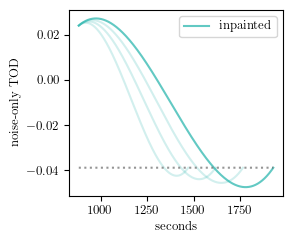

<Figure size 640x480 with 0 Axes>

In [ ]:
####################################################
# INPAINTING
####################################################

n_samples_sub = n_samples_pow//16
TOD_oof = tod_chunk[:n_samples_sub]
nsamp_y = len(TOD_oof)

### Plotting and comparing the input and output maps
plt.figure(figsize=(3, 2.5))

#plt.plot(np.arange(n_samples_pow)/sampling_rate_hz,tod_chunk, color='lightgray')

for nsamp_x in [10000, 12500, 15000, n_samples_pow - nsamp_y]:
    n_samp_assumed = nsamp_x + nsamp_y

    freqs = np.fft.fftfreq(n_samp_assumed, d=1/sampling_rate_hz) 

    sigma = net_detector_ukrts * np.sqrt(sampling_rate_hz) / 1e6 #as in rescale_noise
    P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

    b = -A_func(P_oof, TOD_oof, nsamp_x, left=True)	#A_func applied to a vector [0,y]

    def A_func_x_only(x):
        return A_func(P_oof, x, nsamp_x, right=True)	#A_func applied to a vector [x,0]

    # Define the LinearOperator for CG
    A_op = LinearOperator((nsamp_x,nsamp_x), matvec=A_func_x_only)

    ## in case we want to add an initial guess for x
    avg_head = np.mean(TOD_oof[:nsamp_avg])
    avg_tail = np.mean(TOD_oof[-nsamp_avg:])
    x0 = avg_tail + np.arange(nsamp_x)/nsamp_x*(avg_head-avg_tail)

    start = time.time()

    x_sol, info = cg(A_op, b, rtol=1e-10, x0=x0)

    if info == 0:
        print("it took "+str((time.time()-start)/60)+" minutes to converge!")
    else:
        print("CG did not converge, info =", info)

    if nsamp_x == n_samples_pow - nsamp_y:
        plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,x_sol, color='lightseagreen', alpha=0.7, label=r'inpainted')
    else:
        plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,x_sol, color='lightseagreen', alpha=0.2)
        

plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,np.ones(nsamp_x)*x_sol[-1], color='dimgrey', alpha=0.7, linestyle=':')
#plt.plot(np.arange(nsamp_y)/sampling_rate_hz,TOD_oof, color='teal', label=r'simulated')
plt.xlabel(r'seconds')
plt.ylabel(r'noise-only TOD')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("output/inp_length.pdf")
plt.show()
plt.clf()

In [14]:
print(sampling_rate_hz)
print(fknee_mhz*1e-3)

sampling_rate_hz/(fknee_mhz*1e-3)

17.012412604253807
0.1


170.12412604253805

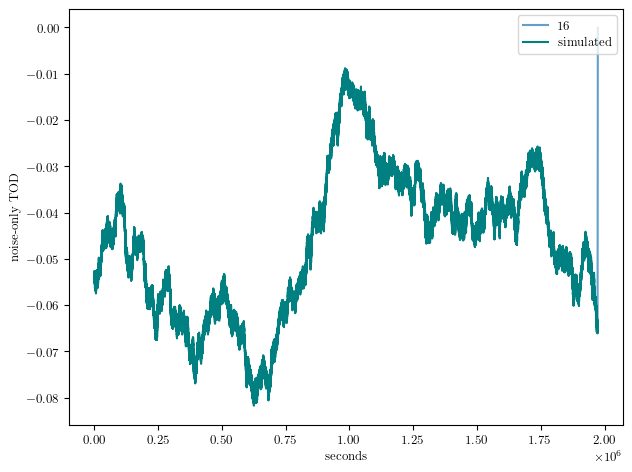

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz, x_sol_10_binned_spline, alpha=0.7, label=f'{bin_size}')
plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,np.ones(nsamp_x)*x_sol[-1], color='dimgrey', alpha=0.7, linestyle=':')
plt.plot(np.arange(nsamp_y)/sampling_rate_hz,TOD_oof, color='teal', label=r'simulated')
plt.xlabel(r'seconds')
plt.ylabel(r'noise-only TOD')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("output/bin_size.pdf")
plt.show()
plt.clf()

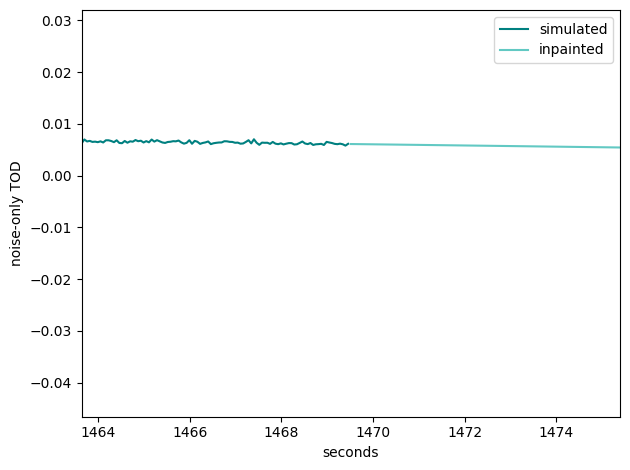

<Figure size 640x480 with 0 Axes>

In [49]:
plt.plot(np.arange(nsamp_y)/sampling_rate_hz,TOD_oof, color='teal', label='simulated')
plt.plot(nsamp_y/sampling_rate_hz+np.arange(nsamp_x)/sampling_rate_hz,x_sol, color='lightseagreen', alpha=0.7, label='inpainted')
plt.xlabel('seconds')
plt.ylabel('noise-only TOD')
plt.legend(loc='upper right')
plt.xlim((nsamp_y-100)/sampling_rate_hz,(nsamp_y+100)/sampling_rate_hz)
plt.tight_layout()
plt.show()
plt.clf()


In [50]:
####################################################
# INPAINTING
####################################################

TOD_oof = TOD_oof_1

nsamp = len(TOD_oof)

freqs = np.fft.rfftfreq(2*nsamp, d=1/sampling_rate_hz) #2*nsamp!

sigma = net_detector_ukrts * np.sqrt(sampling_rate_hz) / 1e6 #as in rescale_noise
P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

def check_lr(left,right):
    '''
    Checks if the arguments left and right are well defined (they must be different)
    '''
    if left == right:
        print('one (and only one) argument between left and right must be True!')
        quit()

def check_Pv(P,v):
    '''
    Checks if the arguments P and v are well defined (len(v) must be len(P)-1)
    '''
    if len(v) != len(P)-1:
        print('len(v) must be len(P)-1!')
        quit()

def padding(v,N,left=False,right=False):
    '''
    Given v, returns a padded vector, (0,v) or (v,0) depending on whether left or right are True.
    
    ARGUMENTS____________________________________________ 
    v:     vector to be padded
    N:     final length of the padded vector
    left:  if true, returns (0,v) 
    right: if true, returns (v,0) 
    '''
    check_lr(left,right)
    n = len(v)
    z = np.zeros(N)
    if right == True:
        z[:n] = v
    elif left == True:
        z[-n:] = v    
    return z

def A_func(P,v,left=False,right=False):    
    # z = padded v
    # A(z) = IDFT(1/P * DFT(z))
    check_lr(left,right)
    check_Pv(P,v)
    n = len(v)
    N = 2*n
    z = padding(v,N,left,right)
    z_fft = np.fft.rfft(z)
    product = 1/P * z_fft
    result = np.fft.irfft(product).real
    return result[:n]

def A_func_x_only(x):
    return A_func(P_oof, x, right=True)	#A_func applied to a vector [x,0]

b = -A_func(P_oof, TOD_oof, left=True)	#A_func applied to a vector [0,y]

# Define the LinearOperator for CG
A_op = LinearOperator((nsamp,nsamp), matvec=A_func_x_only)

## in case we want to add an initial guess for x
avg_head = np.mean(TOD_oof[:nsamp_avg])
avg_tail = np.mean(TOD_oof[-nsamp_avg:])
x0 = avg_tail + np.arange(nsamp)/nsamp*(avg_head-avg_tail)

start = time.time()

x_sol, info = cg(A_op, b, rtol=1e-10, x0=x0)

if info == 0:
    print("it took "+str((time.time()-start)/60)+" minutes to converge!")
else:
    print("CG did not converge, info =", info)

#plt.plot(np.arange(nsamp),TOD_oof, label='TOD_oof')
plt.plot(np.arange(2*nsamp),np.ones(2*nsamp)*x_sol[0], color='dimgrey', alpha=0.7, linestyle=':')
plt.plot(np.arange(nsamp),x_sol, color='lightseagreen', alpha=0.7, label='inpainted')
plt.plot(nsamp+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
plt.clf()


NameError: name 'TOD_oof_1' is not defined

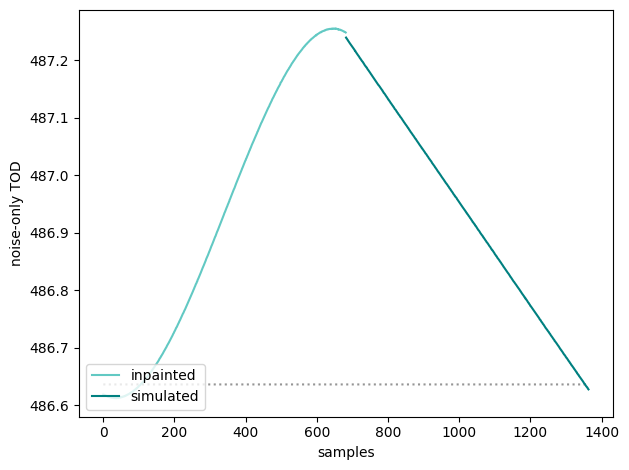

<Figure size 640x480 with 0 Axes>

In [ ]:
#plt.plot(np.arange(nsamp),TOD_oof, label='TOD_oof')
plt.plot(np.arange(2*nsamp),np.ones(2*nsamp)*x_sol[0], color='dimgrey', alpha=0.7, linestyle=':')
plt.plot(np.arange(nsamp),x_sol+oof_only, color='lightseagreen', alpha=0.7, label='inpainted')
plt.plot(nsamp+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
plt.clf()

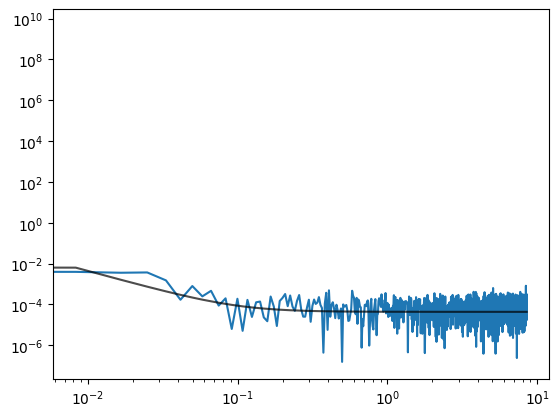

In [ ]:
plt.loglog(freqs, np.abs(np.fft.rfft(np.concatenate((x_sol+oof_only,TOD_oof)))**2))
plt.loglog(freqs, P_oof, color='black', alpha=0.7, label='theoretical')

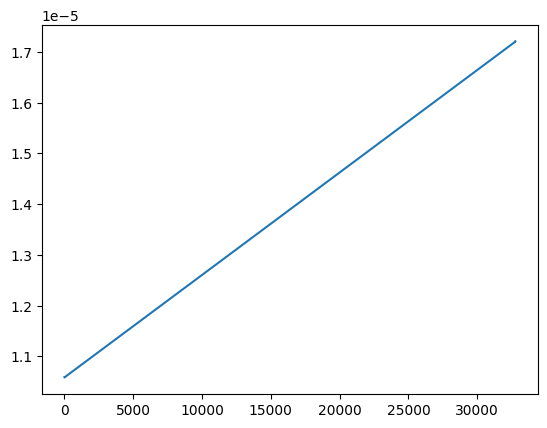

In [ ]:
plt.plot(x_sol-x0)

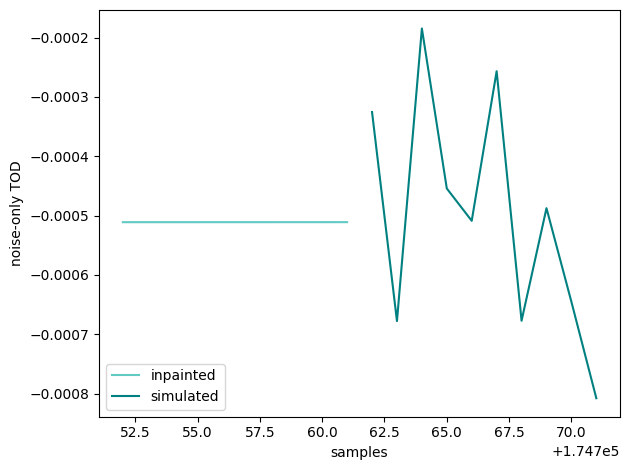

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(np.arange(nsamp)[-10:],x_sol[-10:], color='lightseagreen', alpha=0.7, label='inpainted')
plt.plot(nsamp+np.arange(nsamp)[:10],TOD_oof[:10], color='teal', label='simulated')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
plt.clf()

In [ ]:
TOD_oof = tod_chunk[:int(len(tod_chunk)/n_subchunks)]

simulating 1.6051025390625002 hours of data
it took 2.475954798857371 minutes to converge!


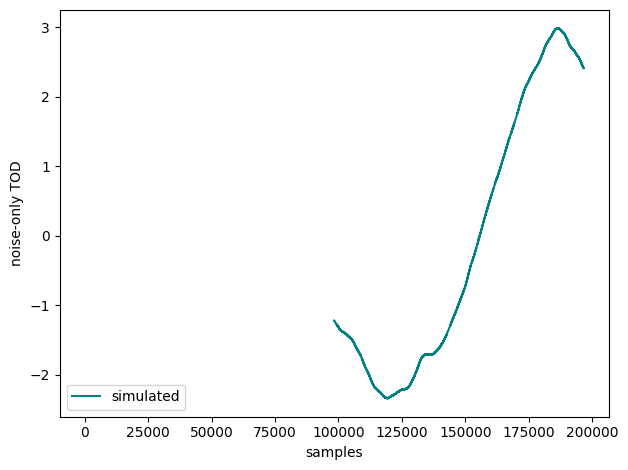

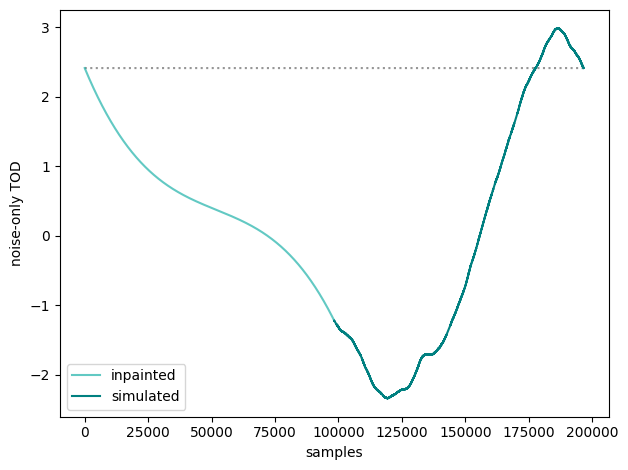

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.sparse.linalg import cg, LinearOperator
import time

####################################################
# GENERATE NOISE
####################################################

import litebird_sim as lbs

nsamp = int(2**16*1.5) #away from 2^n

net_ukrts=100

n_samples_pow = 2**29                          
sampling_rate_hz = n_samples_pow/3600/24/365.25 # corresponding to 365.25 days of mission (~17 Hz)

alpha=4
fknee_mhz=100
fmin_hz=1e-5
duration_s=nsamp/sampling_rate_hz

print('simulating '+str(duration_s/3600)+' hours of data')

sigma = net_ukrts * np.sqrt(sampling_rate_hz) / 1e6 #as in rescale_noise

# Create a simulation lasting 1000 seconds
sim = lbs.Simulation(
    base_path='output',
    start_time=0,
    duration_s=duration_s,
    random_seed=12345,
    imo=imo,
)

det = lbs.DetectorInfo(
  net_ukrts=net_ukrts,
  sampling_rate_hz=sampling_rate_hz,
  alpha=alpha,
  fknee_mhz=fknee_mhz,
  fmin_hz=fmin_hz
)

obs = sim.create_observations(detectors=[det])

# Here we add white noise using the detector
# noise parameters from the `det` object.
# We use the random number generator provided
# by `sim`, which is initialized with the
# seed we passed to the Simulation constructor
# to ensure repeatability.
lbs.noise.add_noise_to_observations(obs, 'one_over_f', dets_random=sim.dets_random)

TOD_oof = obs[0].tod[0]

####################################################
# INPAINTING
####################################################

nsamp = len(TOD_oof)

freqs = np.fft.rfftfreq(2*nsamp, d=1/sampling_rate_hz) #2*nsamp!
P_oof = sigma**2*(freqs**alpha + (fknee_mhz*1e-3)**alpha)/(freqs**alpha + fmin_hz**alpha)*len(freqs)

def check_lr(left,right):
    '''
    Checks if the arguments left and right are well defined (they must be different)
    '''
    if left == right:
        print('one (and only one) argument between left and right must be True!')
        quit()

def check_Pv(P,v):
    '''
    Checks if the arguments P and v are well defined (len(v) must be len(P)-1)
    '''
    if len(v) != len(P)-1:
        print('len(v) must be len(P)-1!')
        quit()

def padding(v,N,left=False,right=False):
    '''
    Given v, returns a padded vector, (0,v) or (v,0) depending on whether left or right are True.
    
    ARGUMENTS____________________________________________ 
    v:     vector to be padded
    N:     final length of the padded vector
    left:  if true, returns (0,v) 
    right: if true, returns (v,0) 
    '''
    check_lr(left,right)
    n = len(v)
    z = np.zeros(N)
    if right == True:
        z[:n] = v
    elif left == True:
        z[-n:] = v    
    return z

def A_func(P,v,left=False,right=False):    
    # z = padded v
    # A(z) = IDFT(1/P * DFT(z))
    check_lr(left,right)
    check_Pv(P,v)
    n = len(v)
    N = 2*n
    z = padding(v,N,left,right)
    z_fft = np.fft.rfft(z)
    product = 1/P * z_fft
    result = np.fft.irfft(product).real
    return result[:n]

def A_func_x_only(x):
    return A_func(P_oof, x, right=True)	#A_func applied to a vector [x,0]

b = -A_func(P_oof, TOD_oof, left=True)	#A_func applied to a vector [0,y]

# Define the LinearOperator for CG
A_op = LinearOperator((nsamp,nsamp), matvec=A_func_x_only)

### in case we want to add an initial guess for x
avg_head = np.mean(TOD_oof[:nsamp_avg])
avg_tail = np.mean(TOD_oof[-nsamp_avg:])
x0 = avg_tail + np.arange(nsamp)/nsamp*(avg_head-avg_tail)

start = time.time()

x_sol, info = cg(A_op, b, rtol=1e-10)

if info == 0:
    print("it took "+str((time.time()-start)/60)+" minutes to converge!")
else:
    print("CG did not converge, info =", info)
    
plt.plot(np.arange(2*nsamp),np.ones(2*nsamp)*x_sol[0], color='white', alpha=0.7, linestyle=':')
plt.plot(np.arange(nsamp),x_sol, color='white', alpha=0.7)
plt.plot(nsamp+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()#('output/simulated-only.pdf')
plt.clf()

#plt.plot(np.arange(nsamp),TOD_oof, label='TOD_oof')
plt.plot(np.arange(2*nsamp),np.ones(2*nsamp)*x_sol[0], color='dimgrey', alpha=0.7, linestyle=':')
plt.plot(np.arange(nsamp),x_sol, color='lightseagreen', alpha=0.7, label='inpainted')
plt.plot(nsamp+np.arange(nsamp),TOD_oof, color='teal', label='simulated')
plt.xlabel('samples')
plt.ylabel('noise-only TOD')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()#('output/simulated+inpainted.pdf')
plt.clf()


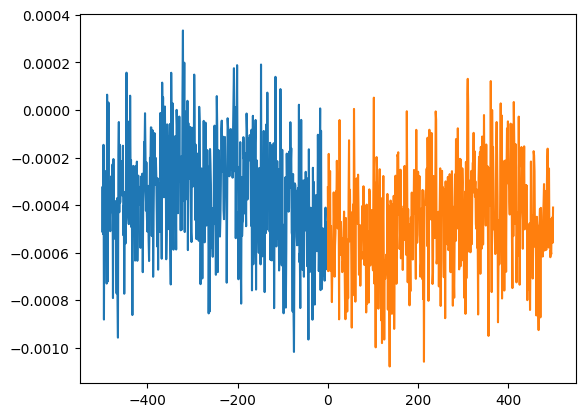

In [ ]:
Nsamp = 500

plt.plot(-Nsamp+np.arange(Nsamp),tod_chunk[-Nsamp:])
plt.plot(np.arange(Nsamp),tod_chunk[:Nsamp])

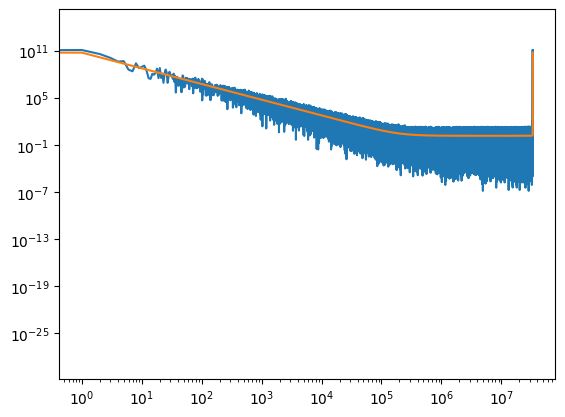

In [ ]:
def P_oof_func(N, sampling_rate_hz, net_ukrts, fknee_mhz, alpha, fmin_hz):
    '''
    Given N, the sampling rate and all 1/f noise parameters, returns P^-1
    '''
    sigma = net_ukrts * np.sqrt(sampling_rate_hz) / 1e6     # as in LBS rescale_noise
    abs_freqs = np.abs(np.fft.fftfreq(N, d=1/sampling_rate_hz))
    P_oof = sigma**2*(abs_freqs**alpha + (fknee_mhz*1e-3)**alpha)/(abs_freqs**alpha + fmin_hz**alpha)*len(abs_freqs)
    return P_oof

freqs = np.fft.fftfreq(n_samples_pow, d = 1/sampling_rate_hz)
Pf_realization = np.abs(np.fft.fft(tod_chunk))**2

plt.loglog(Pf_realization)
plt.loglog(P_oof_func(n_samples_pow, sampling_rate_hz, net_detector_ukrts, fknee_mhz, alpha, fmin_hz))

In [ ]:
tod_temp = tod_chunk[:int(len(tod_chunk)/n_subchunks)]
nsamp_temp = len(tod_temp)

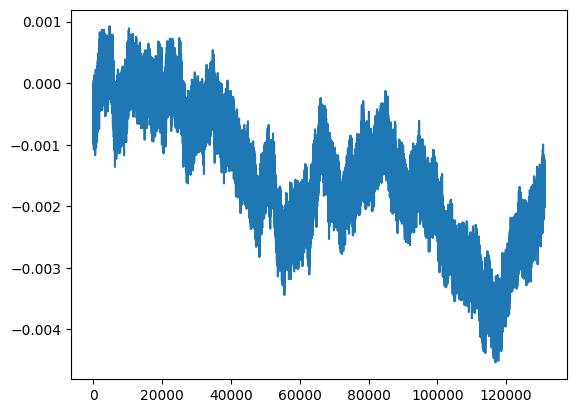

In [ ]:
plt.plot(tod_temp)

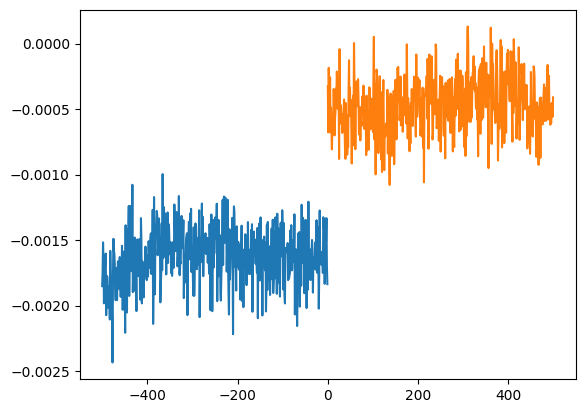

In [ ]:
Nsamp = 500

plt.plot(-Nsamp+np.arange(Nsamp),tod_temp[-Nsamp:])
plt.plot(np.arange(Nsamp),tod_temp[:Nsamp])

In [ ]:
# total length of the inpainted TOD
nsamp_inpainted = 2*nsamp_temp

time_ordered_data = np.zeros(nsamp_inpainted)

start_idx = 0
end_idx = nsamp_temp
time_ordered_data[start_idx:end_idx] = tod_temp

start_idx = end_idx
end_idx += nsamp_temp

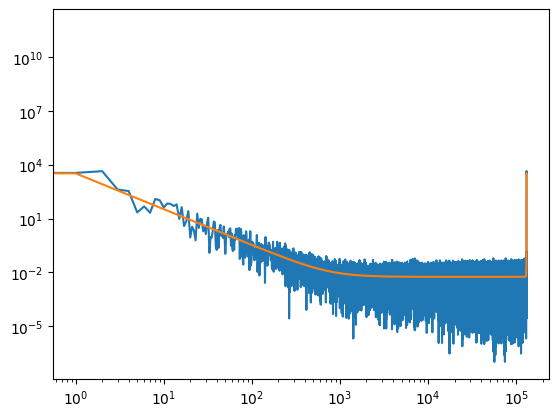

In [ ]:
freqs = np.fft.fftfreq(nsamp_temp, d = 1/sampling_rate_hz)
Pf_realization = np.abs(np.fft.fft(tod_temp))**2

plt.loglog(Pf_realization)
plt.loglog(P_oof_func(nsamp_temp, sampling_rate_hz, net_detector_ukrts, fknee_mhz, alpha, fmin_hz))

In [ ]:
nn = 1 #FIXME: by hand, but smaller than detector_sampling_freq/(fknee_mhz*1e-3) = 5

tod_temp_binned = np.empty(int(nsamp_temp/nn))

for i in range(len(tod_temp_binned)):
    tod_temp_binned[i] = np.mean(tod_temp[i*nn:(i+1)*nn])

nsamp_binned = len(tod_temp_binned)
nsamp_inpainted_binned = 2*nsamp_binned

nyquist_binned = sampling_rate_hz/2/nn

freqs = np.fft.fftfreq(nsamp_inpainted, d=1/sampling_rate_hz)
mask_freqs = np.where((freqs<nyquist_binned) & (freqs>=-nyquist_binned))

# inverse of the 1/f power spectra
P_oof_inv_binned = P_oof_inv[mask_freqs]*nn

In [ ]:
# inverse of the 1/f power spectra
P_oof_inv = 1/P_oof_func(nsamp_inpainted, sampling_rate_hz, net_detector_ukrts, fknee_mhz, alpha, fmin_hz)

In [ ]:
tod_temp_binned = tod_temp
P_oof_inv_binned = P_oof_inv
nsamp_binned = nsamp_temp
nsamp_inpainted_binned = nsamp_inpainted

In [ ]:
def A_func_left(Pinv, y, N):   
    '''
    Given y, pads it to the left and returns the first len(x) elements of IDFT(1/P * DFT[0,y]))
    
    ARGUMENTS____________________________________________ 
    Pinv:  inverse of the power spectrum
    y:     vector to be padded
    N:     total length of the padded vector (same as inpainted TOD)
    ''' 
    n = len(y)
    z = np.concatenate((np.zeros(N-n), y))
    z_fft = np.fft.fft(z)
    product = Pinv * z_fft
    result = np.fft.ifft(product)
    return result[:N-n]

# -IDFT(1/P * DFT([0,y]))
b_binned = -A_func_left(P_oof_inv_binned, tod_temp_binned, nsamp_inpainted_binned)

lenx_binned = nsamp_inpainted_binned - nsamp_binned

# we need a function of x only to build the LinearOperator for CG
def A_func_x_only_binned(x):   
    # Given x, computes A_func(P_oof_inv, x, nsamp_inpainted, right=True)
    
    z = np.concatenate((x, np.zeros(nsamp_binned)))
    z_fft = np.fft.fft(z)
    product = P_oof_inv_binned * z_fft
    result = np.fft.ifft(product)
    return result[:lenx_binned]

# Define the LinearOperator for CG
A_op_binned = LinearOperator((lenx_binned,lenx_binned), matvec=A_func_x_only_binned)

In [ ]:
x0 = np.linspace(np.mean(tod_temp[-10:]), np.mean(tod_temp[:10]), lenx_binned)

In [ ]:
x_sol_10_binned, info = cg(A_op_binned, b_binned, x0=x0, rtol=1e-15)

In [ ]:
info

0

In [ ]:
#x = nn*(1/2 + np.arange(nsamp_binned))
x = np.arange(nsamp_temp)
y = x_sol_10_binned
cs = CubicSpline(x, y)

x_sol_10_binned_spline = cs(np.arange(nsamp_temp))

time_ordered_data[start_idx:end_idx] = x_sol_10_binned_spline

/var/folders/wl/0xvr4dp16v1dx8h0clwghf6r0000gn/T/ipykernel_926/1133401672.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  time_ordered_data[start_idx:end_idx] = x_sol_10_binned_spline


In [ ]:
time_ordered_data[start_idx:end_idx] = x_sol_10_binned

/var/folders/wl/0xvr4dp16v1dx8h0clwghf6r0000gn/T/ipykernel_926/1161477623.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  time_ordered_data[start_idx:end_idx] = x_sol_10_binned


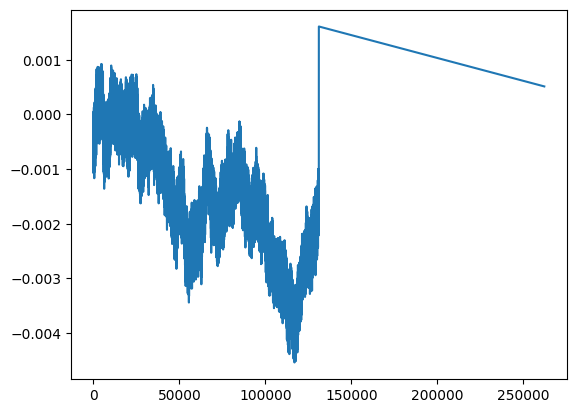

In [ ]:
plt.plot(time_ordered_data)

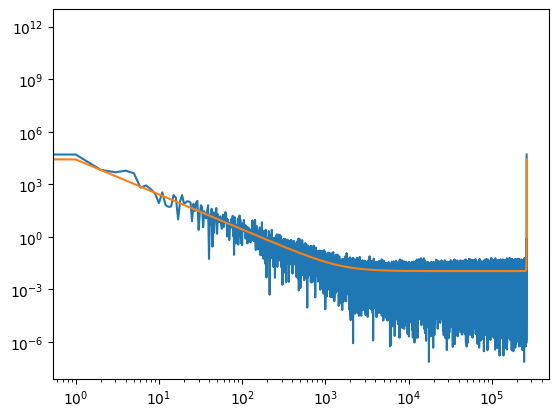

In [ ]:
freqs = np.fft.fftfreq(nsamp_inpainted, d = 1/sampling_rate_hz)
Pf_realization = np.abs(np.fft.fft(time_ordered_data))**2

plt.loglog(Pf_realization)
plt.loglog(P_oof_func(nsamp_inpainted, sampling_rate_hz, net_detector_ukrts, fknee_mhz, alpha, fmin_hz))

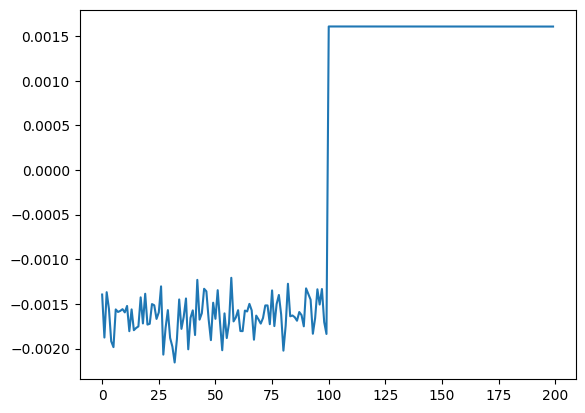

In [ ]:
plt.plot(time_ordered_data[start_idx-100:start_idx+100])

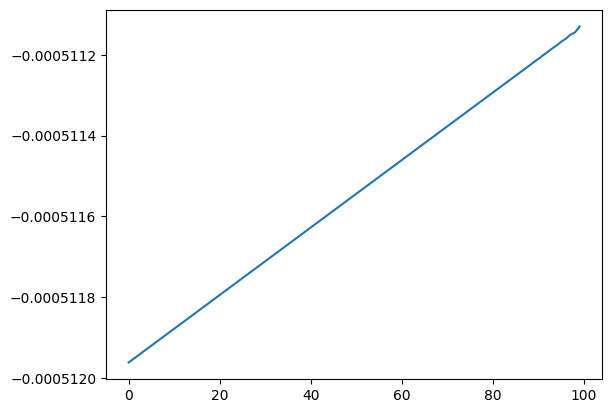

In [ ]:
plt.plot(time_ordered_data[-100:])